In [252]:
# LLAMABARA TEST 2026

# Importing Libraries to solve the test

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Loading the CSV
path = '/content/Test Data.csv'
data = pd.read_csv(path, encoding='latin1')
print(data.head())

     TransId                TransDate    UserName CurrencyStr  Actual_Stake  \
0  151823612  2025-03-31 21:43:45.687  user_95415         IDR         85.60   
1  151825539  2025-03-31 22:11:21.030  user_31040         IDR        250.00   
2  151827917  2025-03-31 22:44:04.950  user_55815         IDR         37.80   
3  151824079  2025-03-31 21:51:56.607  user_95840         IDR        116.16   
4  151825450  2025-03-31 22:10:00.193  user_34200         IDR         43.89   

   Odds  BetType Betteam Status  Winlost  ActualRate Winlostdate  \
0 -1.07        9       a    WON   165.60       0.085  2025-04-01   
1  1.11        7       h   LOSE     0.00       0.085  2025-04-01   
2 -1.26        7       h    WON    67.80       0.085  2025-04-01   
3 -1.21        7       h   LOSE     0.00       0.085  2025-04-01   
4 -1.33        9       a    WON    76.89       0.085  2025-04-01   

   LiveIndicator BetGameTime  MatchId  SportId  LeagueId    WebId  MaxBet  
0          False         NaN  7490913   

In [253]:
print(data.shape)

(842163, 19)


In [254]:
# Main Information of the dataframe
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842163 entries, 0 to 842162
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransId        842163 non-null  int64  
 1   TransDate      842163 non-null  object 
 2   UserName       842163 non-null  object 
 3   CurrencyStr    842006 non-null  object 
 4   Actual_Stake   842163 non-null  float64
 5   Odds           842163 non-null  float64
 6   BetType        842163 non-null  int64  
 7   Betteam        842163 non-null  object 
 8   Status         842163 non-null  object 
 9   Winlost        842163 non-null  float64
 10  ActualRate     842163 non-null  float64
 11  Winlostdate    842163 non-null  object 
 12  LiveIndicator  842163 non-null  bool   
 13  BetGameTime    556470 non-null  object 
 14  MatchId        842163 non-null  int64  
 15  SportId        842163 non-null  int64  
 16  LeagueId       842163 non-null  int64  
 17  WebId          842163 non-nul

In [255]:
# Main Statistical variables for each column
print(data.describe())

            TransId  Actual_Stake           Odds       BetType       Winlost  \
count  8.421630e+05  8.421630e+05  842163.000000  842163.00000  8.421630e+05   
mean   2.441787e+08  1.353956e+03       2.851226       3.49707  1.263118e+03   
std    7.783851e+07  4.700322e+04      16.071716       2.80909  6.364447e+04   
min    1.253860e+08  1.500000e-01    -100.000000       1.00000  0.000000e+00   
25%    1.524887e+08  3.472000e+01      -1.010000       1.00000  0.000000e+00   
50%    2.859600e+08  1.000000e+02       0.990000       3.00000  2.290000e+01   
75%    2.967148e+08  2.775000e+02       1.260000       5.00000  1.710000e+02   
max    3.213648e+08  1.500000e+07     300.000000       9.00000  3.074000e+07   

          ActualRate       MatchId        SportId       LeagueId        MaxBet  
count  842163.000000  8.421630e+05  842163.000000  842163.000000  8.066380e+05  
mean        0.080369  8.030200e+06       1.023861   11058.526767  2.317084e+05  
std         0.099112  1.049090e+05  

In [256]:
# Nan Data for each column (CurrencyStr, BetGameTime, Max Bet)
data.isnull().sum()

,0
TransId,0
TransDate,0
UserName,0
CurrencyStr,157
Actual_Stake,0
Odds,0
BetType,0
Betteam,0
Status,0
Winlost,0


In [257]:
# Unique values for each column
unique_values={col:data[col].unique() for col in data.columns }
for col, values in unique_values.items():
  print(f"Columna: {col}")
  print(f"numero de valores unicos: {len(values)}")
  print(f"valores unicos: {values[:10]}")
  print("--"*50)

Columna: TransId
numero de valores unicos: 840726
valores unicos: [151823612 151825539 151827917 151824079 151825450 151826976 151824532
 151825097 151827699 151827736]
----------------------------------------------------------------------------------------------------
Columna: TransDate
numero de valores unicos: 832145
valores unicos: ['2025-03-31 21:43:45.687' '2025-03-31 22:11:21.030'
 '2025-03-31 22:44:04.950' '2025-03-31 21:51:56.607'
 '2025-03-31 22:10:00.193' '2025-03-31 22:31:38.977'
 '2025-03-31 21:58:08.127' '2025-03-31 22:05:28.093'
 '2025-03-31 22:40:28.770' '2025-03-31 22:41:13.593']
----------------------------------------------------------------------------------------------------
Columna: UserName
numero de valores unicos: 108315
valores unicos: ['user_95415' 'user_31040' 'user_55815' 'user_95840' 'user_34200'
 'user_64689' 'user_81574' 'user_74210' 'user_100650' 'user_57004']
----------------------------------------------------------------------------------------------

In [258]:
data.duplicated().sum()

np.int64(1437)

In [259]:
duplicates = data[data.duplicated()]

# View EVERY instance of a duplicate
all_duplicates = data[data.duplicated(keep=False)]
print(duplicates)

          TransId                TransDate    UserName CurrencyStr  \
840726  284824009  2025-04-04 15:49:20.610  user_22194         IDR   
840727  292207229  2025-04-20 08:56:25.957  user_14769         IDR   
840728  152937579  2025-04-07 15:08:36.317  user_48504         THB   
840729  155062973  2025-04-20 15:37:48.257  user_85572         THB   
840730  285312266  2025-04-05 11:34:24.477  user_20084         IDR   
...           ...                      ...         ...         ...   
842158  287415276  2025-04-10 05:02:16.030  user_99082         IDR   
842159  285573432  2025-04-06 00:31:44.637  user_14231         THB   
842160  288133243  2025-04-11 15:23:56.867  user_44194         THB   
842161  286425326  2025-04-07 15:49:46.130  user_73420         IDR   
842162  287505369  2025-04-10 09:05:09.153  user_50756         THB   

        Actual_Stake  Odds  BetType Betteam Status  Winlost  ActualRate  \
840726          50.0  1.01        1       a   DRAW     50.0    0.085000   
840727   

In [260]:
data_cleaned = data.drop_duplicates()
data_cleaned.isnull().sum()

,0
TransId,0
TransDate,0
UserName,0
CurrencyStr,157
Actual_Stake,0
Odds,0
BetType,0
Betteam,0
Status,0
Winlost,0


In [261]:
# Obtaining the mean of each currency type to know how difference are between them
data.groupby(['CurrencyStr'])['Actual_Stake'].mean(numeric_only=True)

,Actual_Stake
CurrencyStr,
AUD,1.855455e+01
BDT,2.500000e+02
BRL,3.719000e+01
CNY,6.507604e+02
COP,4.000000e+03
HKD,1.004625e+03
IDO,1.642890e+05
IDR,2.488717e+02
INR,9.600000e+01


In [262]:
# Re-create data_cleaned to restore nulls in 'CurrencyStr' before imputation
data_cleaned_impute = data.drop_duplicates().copy()

# Calculate mean Actual_Stake for each non-null CurrencyStr
# Using only the rows where CurrencyStr is not null to get the mean for each currency.
currency_mean_stakes = data_cleaned_impute.dropna(subset=['CurrencyStr']).groupby('CurrencyStr')['Actual_Stake'].mean()

def get_closest_currency(stake, currency_means):

    # Calculate the absolute difference between the current stake and the mean stake of each currency
    differences = (currency_means - stake).abs()
    # Return the currency with the minimum difference
    return differences.idxmin()

# Apply the function to fill nulls in 'CurrencyStr'

null_currency_indices = data_cleaned_impute['CurrencyStr'].isnull()
data_cleaned_impute.loc[null_currency_indices, 'CurrencyStr'] = \
    data_cleaned_impute.loc[null_currency_indices, 'Actual_Stake'].apply(lambda x: get_closest_currency(x, currency_mean_stakes))

print(f"Missing values in 'CurrencyStr' after imputation: {data_cleaned_impute['CurrencyStr'].isnull().sum()}")

# Display the head of the DataFrame with imputed values
display(data_cleaned_impute.head())

Missing values in 'CurrencyStr' after imputation: 0


,TransId,TransDate,UserName,CurrencyStr,Actual_Stake,Odds,BetType,Betteam,Status,Winlost,ActualRate,Winlostdate,LiveIndicator,BetGameTime,MatchId,SportId,LeagueId,WebId,MaxBet
0,151823612,2025-03-31 21:43:45.687,user_95415,IDR,85.60,-1.07,9,a,WON,165.60,0.085,2025-04-01,False,NaN,7490913,2,187,Web_003,5000.0
1,151825539,2025-03-31 22:11:21.030,user_31040,IDR,250.00,1.11,7,h,LOSE,0.00,0.085,2025-04-01,True,Live,7490913,2,187,Web_003,5000.0
2,151827917,2025-03-31 22:44:04.950,user_55815,IDR,37.80,-1.26,7,h,WON,67.80,0.085,2025-04-01,True,Live,7490913,2,187,Web_009,4000.0
3,151824079,2025-03-31 21:51:56.607,user_95840,IDR,116.16,-1.21,7,h,LOSE,0.00,0.085,2025-04-01,False,NaN,7490913,2,187,Web_003,5000.0
4,151825450,2025-03-31 22:10:00.193,user_34200,IDR,43.89,-1.33,9,a,WON,76.89,0.085,2025-04-01,True,Live,7490913,2,187,Web_003,5000.0


In [263]:
data_cleaned_impute.isnull().sum()

,0
TransId,0
TransDate,0
UserName,0
CurrencyStr,0
Actual_Stake,0
Odds,0
BetType,0
Betteam,0
Status,0
Winlost,0


In [264]:
data_cleaned_impute["TransDate"]= pd.to_datetime(data_cleaned_impute["TransDate"])
data_cleaned_impute["Year"]= data_cleaned_impute["TransDate"].dt.year
data_cleaned_impute["Month"]=data_cleaned_impute["TransDate"].dt.month
data_cleaned_impute["Semester"]=data_cleaned_impute["Month"].apply(lambda x:1 if x<=6 else 2)
data_cleaned_impute["Trimester"]=data_cleaned_impute["Month"].apply(lambda x: 1 if x<=3 else (2 if x<=6 else (3 if x<=9 else 4)))
data_cleaned_impute["Day"]=data_cleaned_impute["TransDate"].dt.day
data_cleaned_impute.head()

,TransId,TransDate,UserName,CurrencyStr,Actual_Stake,Odds,BetType,Betteam,Status,Winlost,...,MatchId,SportId,LeagueId,WebId,MaxBet,Year,Month,Semester,Trimester,Day
0,151823612,2025-03-31 21:43:45.687,user_95415,IDR,85.60,-1.07,9,a,WON,165.60,...,7490913,2,187,Web_003,5000.0,2025,3,1,1,31
1,151825539,2025-03-31 22:11:21.030,user_31040,IDR,250.00,1.11,7,h,LOSE,0.00,...,7490913,2,187,Web_003,5000.0,2025,3,1,1,31
2,151827917,2025-03-31 22:44:04.950,user_55815,IDR,37.80,-1.26,7,h,WON,67.80,...,7490913,2,187,Web_009,4000.0,2025,3,1,1,31
3,151824079,2025-03-31 21:51:56.607,user_95840,IDR,116.16,-1.21,7,h,LOSE,0.00,...,7490913,2,187,Web_003,5000.0,2025,3,1,1,31
4,151825450,2025-03-31 22:10:00.193,user_34200,IDR,43.89,-1.33,9,a,WON,76.89,...,7490913,2,187,Web_003,5000.0,2025,3,1,1,31


In [265]:
# Calculate the profit
data_cleaned_impute["House_Profit_SGD"]= (data_cleaned_impute["Actual_Stake"]-data_cleaned_impute["Winlost"])*data_cleaned_impute["ActualRate"]
data_cleaned_impute["Actual_Stake_SGD"]= (data_cleaned_impute["Actual_Stake"])*data_cleaned_impute["ActualRate"]
data_cleaned_impute["Winlost_SGD"]= (data_cleaned_impute["Winlost"])*data_cleaned_impute["ActualRate"]
data_cleaned_impute.head()

,TransId,TransDate,UserName,CurrencyStr,Actual_Stake,Odds,BetType,Betteam,Status,Winlost,...,WebId,MaxBet,Year,Month,Semester,Trimester,Day,House_Profit_SGD,Actual_Stake_SGD,Winlost_SGD
0,151823612,2025-03-31 21:43:45.687,user_95415,IDR,85.60,-1.07,9,a,WON,165.60,...,Web_003,5000.0,2025,3,1,1,31,-6.8000,7.27600,14.07600
1,151825539,2025-03-31 22:11:21.030,user_31040,IDR,250.00,1.11,7,h,LOSE,0.00,...,Web_003,5000.0,2025,3,1,1,31,21.2500,21.25000,0.00000
2,151827917,2025-03-31 22:44:04.950,user_55815,IDR,37.80,-1.26,7,h,WON,67.80,...,Web_009,4000.0,2025,3,1,1,31,-2.5500,3.21300,5.76300
3,151824079,2025-03-31 21:51:56.607,user_95840,IDR,116.16,-1.21,7,h,LOSE,0.00,...,Web_003,5000.0,2025,3,1,1,31,9.8736,9.87360,0.00000
4,151825450,2025-03-31 22:10:00.193,user_34200,IDR,43.89,-1.33,9,a,WON,76.89,...,Web_003,5000.0,2025,3,1,1,31,-2.8050,3.73065,6.53565


### Feature Engineering: Convert `BetGameTime` to Minutes

I will create a new numerical column `BetGameTime_min` from the `BetGameTime` categorical column. The logic for conversion is as follows:

*   For values like `XHXX` (e.g., `1H15`), it will be converted to `(X * 45) + XX` minutes. This assumes a 'half' duration of 45 minutes.
*   `HT` (Half Time) will be converted to 45 minutes.
*   `Live` values and `NaN` values will be converted to `NaN` in the new column, as a numerical conversion is not directly applicable for these states.

In [310]:
import re

def convert_betgametime_to_minutes(betgametime_str):
    if pd.isna(betgametime_str):
        return np.nan

    betgametime_str = str(betgametime_str).strip()

    if betgametime_str == 'HT':
        return 45
    elif betgametime_str == 'Live':
        return np.nan # Or any other agreed upon value if 'Live' implies a specific time

    # Pattern for XHXX, where X is the half number and XX are minutes into the half
    match = re.match(r'(\d+)H(\d+)', betgametime_str)
    if match:
        half_number = int(match.group(1))
        minutes_into_half = int(match.group(2))
        return (half_number * 45) + minutes_into_half

    return np.nan # For any other unhandled string format

# Apply the function to create the new 'BetGameTime_min' column
data_cleaned_impute['BetGameTime_min'] = data_cleaned_impute['BetGameTime'].apply(convert_betgametime_to_minutes)

# Display the head of the DataFrame with the new column and check for nulls
display(data_cleaned_impute[['BetGameTime', 'BetGameTime_min']].head())
print(f"Missing values in 'BetGameTime_min' after conversion: {data_cleaned_impute['BetGameTime_min'].isnull().sum()}")

,BetGameTime,BetGameTime_min
0,NaN,NaN
1,Live,NaN
2,Live,NaN
3,NaN,NaN
4,Live,NaN


Missing values in 'BetGameTime_min' after conversion: 300429


In [266]:
# Total Stake
total_stake = data_cleaned_impute["Actual_Stake_SGD"].sum()
# Total Layout
total_layout = data_cleaned_impute["Winlost_SGD"].sum()
# Net Profit
total_net_profit = data_cleaned_impute["House_Profit_SGD"].sum()
# Margin
margin = data_cleaned_impute["House_Profit_SGD"].sum()/data_cleaned_impute["Actual_Stake_SGD"].sum()
print(f"total stake :{total_stake}")
print(f"total layout :{total_layout}")
print(f"total_net_profit :{total_net_profit}")
print(f"margin :{margin}")

total stake :21468545.707563855
total layout :19138591.540261626
total_net_profit :2329954.1673022215
margin :0.10852873776547081


In [308]:
# Percentage of Fotball and Basketball

total_sport_id_1 = data_cleaned_impute[data_cleaned_impute["SportId"] == 1].shape[0]
total_sport_id_2 = data_cleaned_impute[data_cleaned_impute["SportId"] == 2].shape[0]
fotbal_percentage = (total_sport_id_1 / data_cleaned_impute.shape[0]) * 100
basketball_percentage = (total_sport_id_2 / data_cleaned_impute.shape[0]) * 100

print(f"Total count for Football: {total_sport_id_1}")
print(f"Total count for Basketball: {total_sport_id_2}")
print(f"Football percentage: {fotbal_percentage:.2f}%")
print(f"Basketball percentage: {basketball_percentage:.2f}%")

Total count for Football: 820660
Total count for Basketball: 20066
Football percentage: 97.61%
Basketball percentage: 2.39%


In [267]:
top_league = data_cleaned_impute.groupby("LeagueId")["House_Profit_SGD"].sum().sort_values(ascending=False).head(11)
print(top_league)

LeagueId
13       1.441320e+06
3        2.202988e+05
6        1.991689e+05
57605    1.563069e+05
4        1.044135e+05
187      8.713290e+04
86       5.769168e+04
48952    4.947407e+04
136      3.003316e+04
56025    2.163490e+04
5       -3.752050e+04
Name: House_Profit_SGD, dtype: float64


In [268]:
league_id_mapping = {
    3: 'English Premier League',
    4: 'Italy Serie A',
    5: 'Germany Bundesliga',
    6: 'Spain La Liga',
    13: 'Uefa Champions League',
    86: 'English Championship',
    136: 'Mexico Primera Division',
    187: 'NBA',
    48952: 'Copa Libertadores',
    56025: 'Peru Liga 1',
    57605: 'Indonesia Liga 1'
}

data_cleaned_impute['LeagueName'] = data_cleaned_impute['LeagueId'].map(league_id_mapping)

# Display the top leagues again with their names
top_league_names = data_cleaned_impute.groupby('LeagueName')['House_Profit_SGD'].sum().sort_values(ascending=False).head(11)
print(top_league_names)

LeagueName
Uefa Champions League      1.441320e+06
English Premier League     2.202988e+05
Spain La Liga              1.991689e+05
Indonesia Liga 1           1.563069e+05
Italy Serie A              1.044135e+05
NBA                        8.713290e+04
English Championship       5.769168e+04
Copa Libertadores          4.947407e+04
Mexico Primera Division    3.003316e+04
Peru Liga 1                2.163490e+04
Germany Bundesliga        -3.752050e+04
Name: House_Profit_SGD, dtype: float64


In [269]:
top_website = data_cleaned_impute.groupby("WebId")["House_Profit_SGD"].sum().sort_values(ascending=False).head(11)
print(top_website)

WebId
Web_002    617743.104050
Web_004    331592.675080
Web_005    322462.890880
Web_001    291246.024445
Web_010    164853.922860
Web_003    157441.959750
Web_008    141815.821094
Web_006    119995.251797
Web_007     97597.019281
Web_009     85205.498064
Name: House_Profit_SGD, dtype: float64


In [270]:
web_id_mapping = {

"Web_001": "BetNova",
"Web_002": "WagerZone",
"Web_003": "InkaMaxWin",
"Web_004": "ColossalWin",
"Web_005": "ChasquiPlay",
"Web_006": "FastStake",
"Web_007": "CuscoOdds",
"Web_008": "SureStrike",
"Web_009": "PachaWin",
"Web_010": "InfinityWin"
}

data_cleaned_impute['WebName'] = data_cleaned_impute["WebId"].map(web_id_mapping)

# Display the top leagues again with their names
top_website = data_cleaned_impute.groupby('WebName')['House_Profit_SGD'].sum().sort_values(ascending=False).head(11)
print(top_website)

WebName
WagerZone      617743.104050
ColossalWin    331592.675080
ChasquiPlay    322462.890880
BetNova        291246.024445
InfinityWin    164853.922860
InkaMaxWin     157441.959750
SureStrike     141815.821094
FastStake      119995.251797
CuscoOdds       97597.019281
PachaWin        85205.498064
Name: House_Profit_SGD, dtype: float64


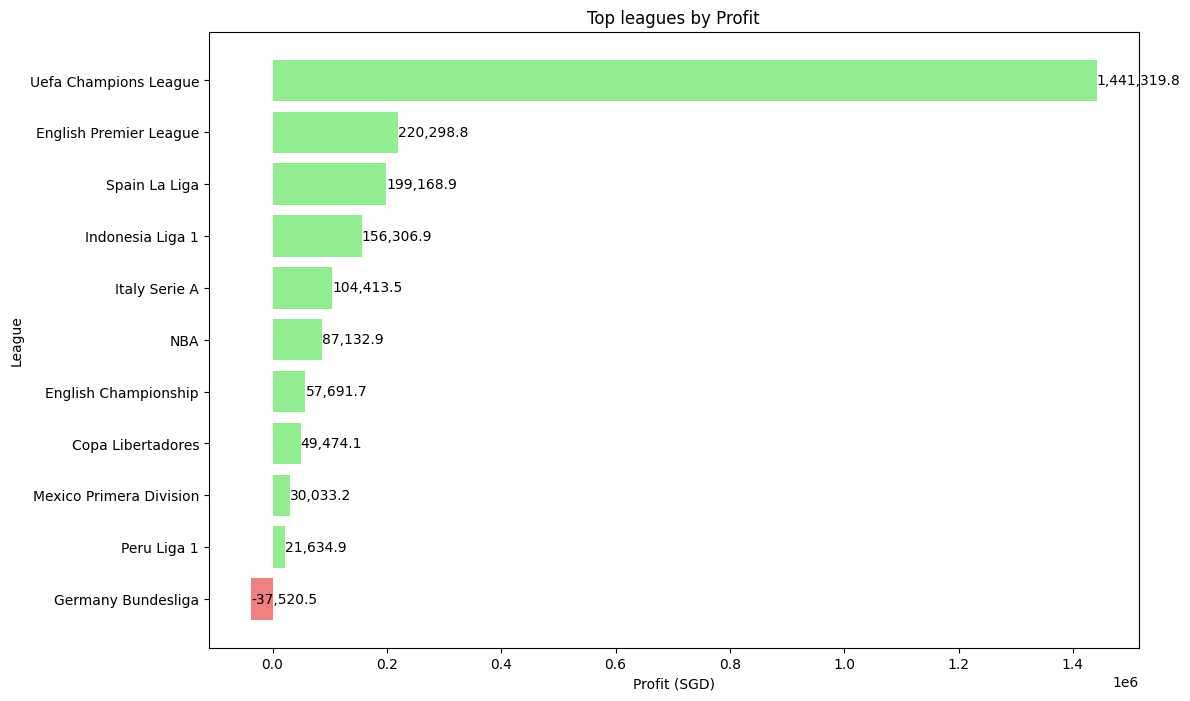

In [271]:
plt.figure(figsize=(12,8))

# Create a list of colors based on profit values
bar_colors = ['lightgreen' if val > 0 else 'lightcoral' for val in top_league_names.values]

plt.barh(top_league_names.index, top_league_names.values, color=bar_colors)
plt.xlabel("Profit (SGD)")
plt.ylabel("League")
plt.gca().invert_yaxis()
plt.title("Top leagues by Profit")

# Add values on top of the bars
for index, value in enumerate(top_league_names.values):
    plt.text(value, index, f'{value:,.1f}', va='center')

plt.show()

In [272]:
# Save the 'Top leagues by Profit' plot as a high-resolution PNG
plt.figure(figsize=(12,4))
bar_colors = ['lightgreen' if val > 0 else 'lightcoral' for val in top_league_names.values]
plt.barh(top_league_names.index, top_league_names.values, color=bar_colors)
plt.xlabel("Profit (SGD)")
plt.ylabel("League")
plt.gca().invert_yaxis()
plt.title("Top leagues by Profit")
for index, value in enumerate(top_league_names.values):
    plt.text(value, index, f'{value:,.2f}', va='center')
plt.savefig('top_leagues_by_profit.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice



In [311]:
# Analisis distribucion de BetGameTime

import re

def convert_betgametime_to_minutes(betgametime_str):
    if pd.isna(betgametime_str):
        return np.nan

    betgametime_str = str(betgametime_str).strip()

    if betgametime_str == 'HT':
        return 45
    elif betgametime_str == 'Live':
        return np.nan # Or any other agreed upon value if 'Live' implies a specific time

    # Pattern for XHXX, where X is the half number and XX are minutes into the half
    match = re.match(r'(\d+)H(\d+)', betgametime_str)
    if match:
        half_number = int(match.group(1))
        minutes_into_half = int(match.group(2))
        return (half_number * 45) + minutes_into_half

    return np.nan # For any other unhandled string format

# Apply the function to create the new 'BetGameTime_min' column
data_cleaned_impute['BetGameTime_min'] = data_cleaned_impute['BetGameTime'].apply(convert_betgametime_to_minutes)

# Display the head of the DataFrame with the new column and check for nulls
display(data_cleaned_impute[['BetGameTime', 'BetGameTime_min']].head())
print(f"Missing values in 'BetGameTime_min' after conversion: {data_cleaned_impute['BetGameTime_min'].isnull().sum()}")

,BetGameTime,BetGameTime_min
0,NaN,NaN
1,Live,NaN
2,Live,NaN
3,NaN,NaN
4,Live,NaN


Missing values in 'BetGameTime_min' after conversion: 300429


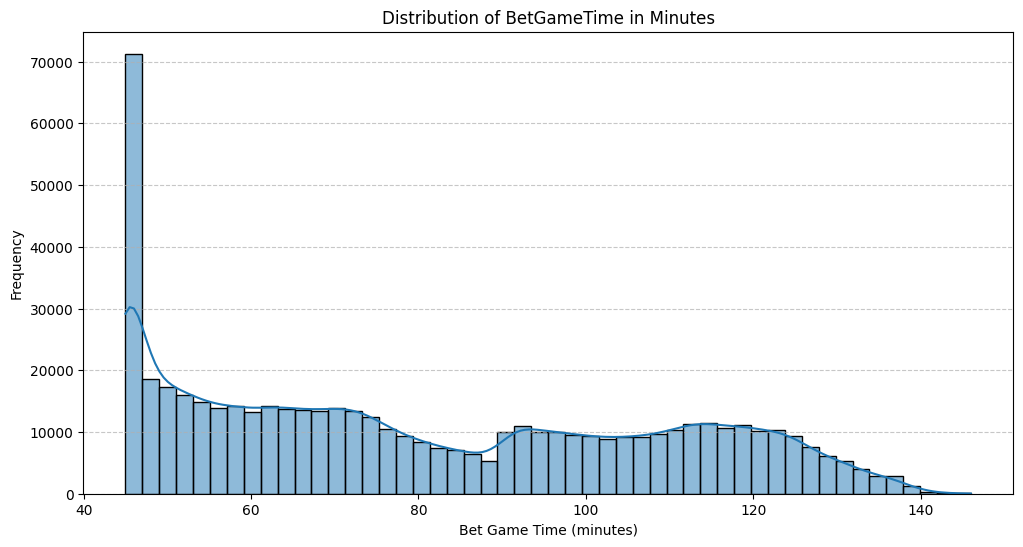

In [312]:
plt.figure(figsize=(12, 6))
sns.histplot(data_cleaned_impute['BetGameTime_min'].dropna(), bins=50, kde=True)
plt.title('Distribution of BetGameTime in Minutes')
plt.xlabel('Bet Game Time (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

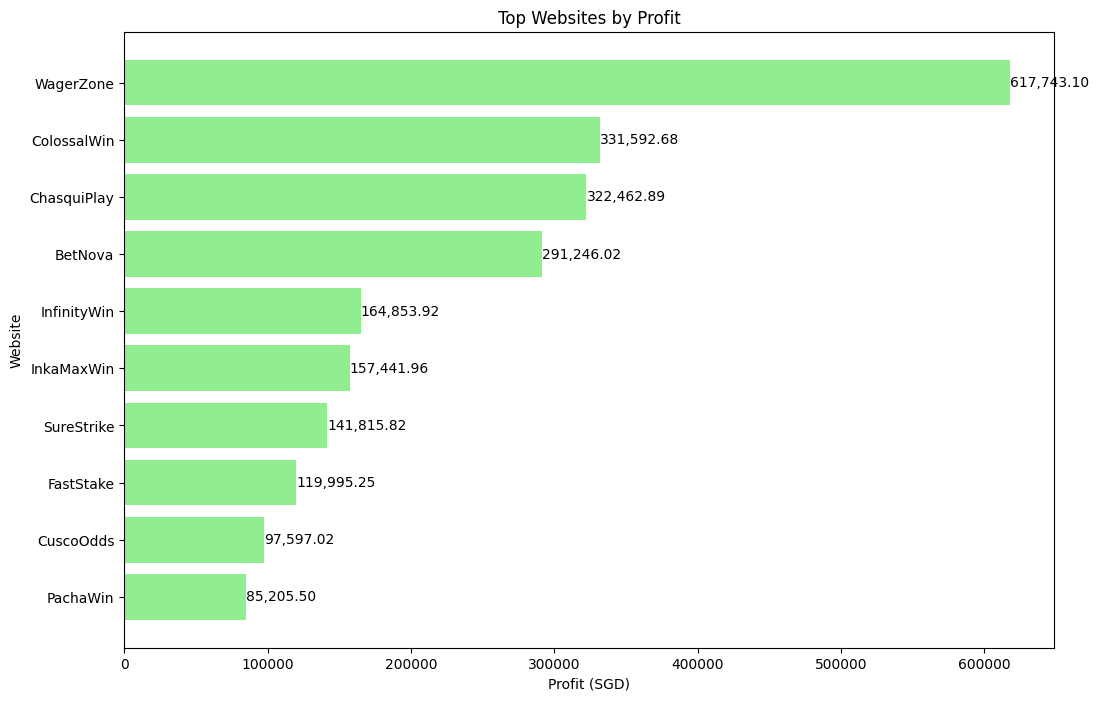

In [273]:
plt.figure(figsize=(12,8))

# Create a list of colors based on profit values
bar_colors_web = ['lightgreen' if val > 0 else 'lightcoral' for val in top_website.values]

plt.barh(top_website.index, top_website.values, color=bar_colors_web)
plt.xlabel("Profit (SGD)")
plt.ylabel("Website")
plt.gca().invert_yaxis()
plt.title("Top Websites by Profit")

# Add values on top of the bars
for index, value in enumerate(top_website.values):
    plt.text(value, index, f'{value:,.2f}', va='center')

plt.show()

In [274]:
# Save the 'Top Websites by Profit' plot as a high-resolution PNG
plt.figure(figsize=(12,4))
bar_colors_web = ['lightgreen' if val > 0 else 'lightcoral' for val in top_website.values]
plt.barh(top_website.index, top_website.values, color=bar_colors_web)
plt.xlabel("Profit (SGD)")
plt.ylabel("Website")
plt.gca().invert_yaxis()
plt.title("Top Websites by Profit")
for index, value in enumerate(top_website.values):
    plt.text(value, index, f'{value:,.2f}', va='center')
plt.savefig('top_websites_by_profit.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

### Probability of Win/Lose based on Live Indicator

In [275]:
live_indicator_analysis = data_cleaned_impute.groupby(['LiveIndicator', 'Status']).size().unstack(fill_value=0)

# Calculate total bets for each LiveIndicator
live_indicator_analysis['Total'] = live_indicator_analysis.sum(axis=1)

# Calculate win/lose probabilities
for status in ['WON', 'LOSE', 'DRAW']:
    if status in live_indicator_analysis.columns:
        live_indicator_analysis[f'{status}_Probability'] = (live_indicator_analysis[status] / live_indicator_analysis['Total']) * 100
    else:
        live_indicator_analysis[f'{status}_Probability'] = 0.0 # If a status is not present, its probability is 0

display(live_indicator_analysis)

Status,D.L.VOID,DRAW,LOSE,REFUND,VOID,WON,Total,WON_Probability,LOSE_Probability,DRAW_Probability
LiveIndicator,,,,,,,,,,
False,0,19981,155995,666,89,80093,256824,31.185948,60.740040,7.780036
True,1456,53896,309015,0,198,219337,583902,37.564009,52.922408,9.230316


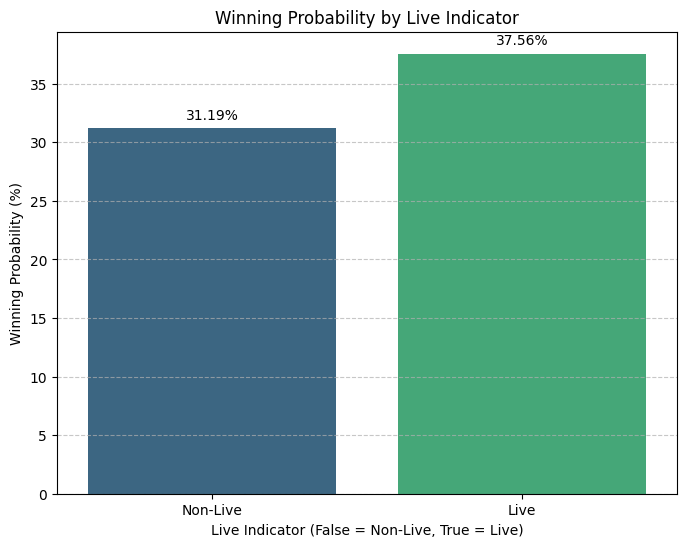

In [276]:
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=live_indicator_analysis.index, y='WON_Probability', hue=live_indicator_analysis.index, data=live_indicator_analysis, palette='viridis', legend=False)
plt.title('Winning Probability by Live Indicator')
plt.xlabel('Live Indicator (False = Non-Live, True = Live)')
plt.ylabel('Winning Probability (%)')
plt.xticks([0, 1], ['Non-Live', 'Live'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for index, value in enumerate(live_indicator_analysis['WON_Probability']):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

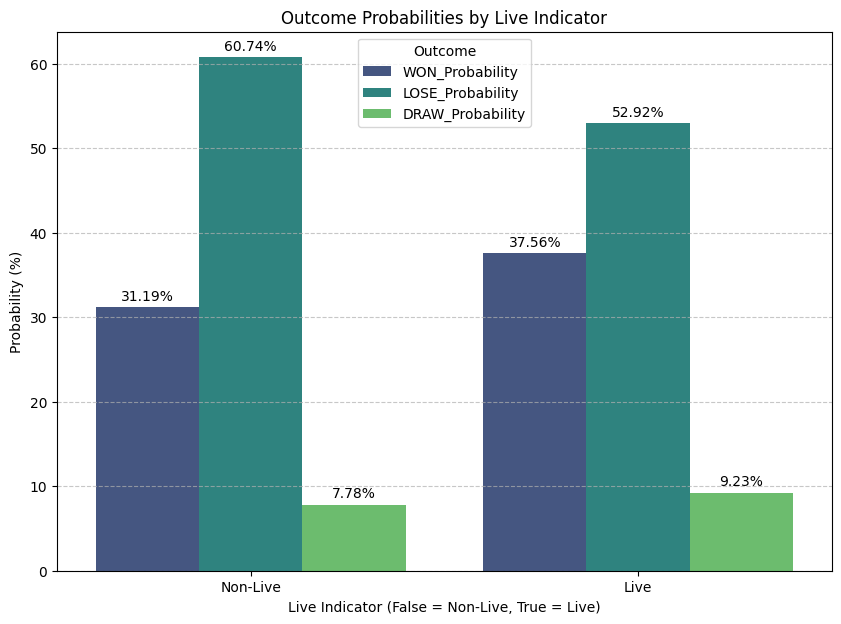

In [277]:
# Prepare data for plotting win, lose, and draw probabilities
plot_data = live_indicator_analysis[['WON_Probability', 'LOSE_Probability', 'DRAW_Probability']].reset_index()
plot_data_melted = plot_data.melt(id_vars='LiveIndicator', var_name='Outcome', value_name='Probability')

plt.figure(figsize=(10, 7))
sns.barplot(x='LiveIndicator', y='Probability', hue='Outcome', data=plot_data_melted, palette='viridis')

plt.title('Outcome Probabilities by Live Indicator')
plt.xlabel('Live Indicator (False = Non-Live, True = Live)')
plt.ylabel('Probability (%)')
plt.xticks([0, 1], ['Non-Live', 'Live'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome')

# Add values on top of the bars
for container in plt.gca().containers:
    for bar in container:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.2f}%',
                 ha='center', va='bottom')

plt.show()

In [278]:
fig.savefig('bet_volume_vs_profit_margin_by_bet_type_high_res.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice if rerun

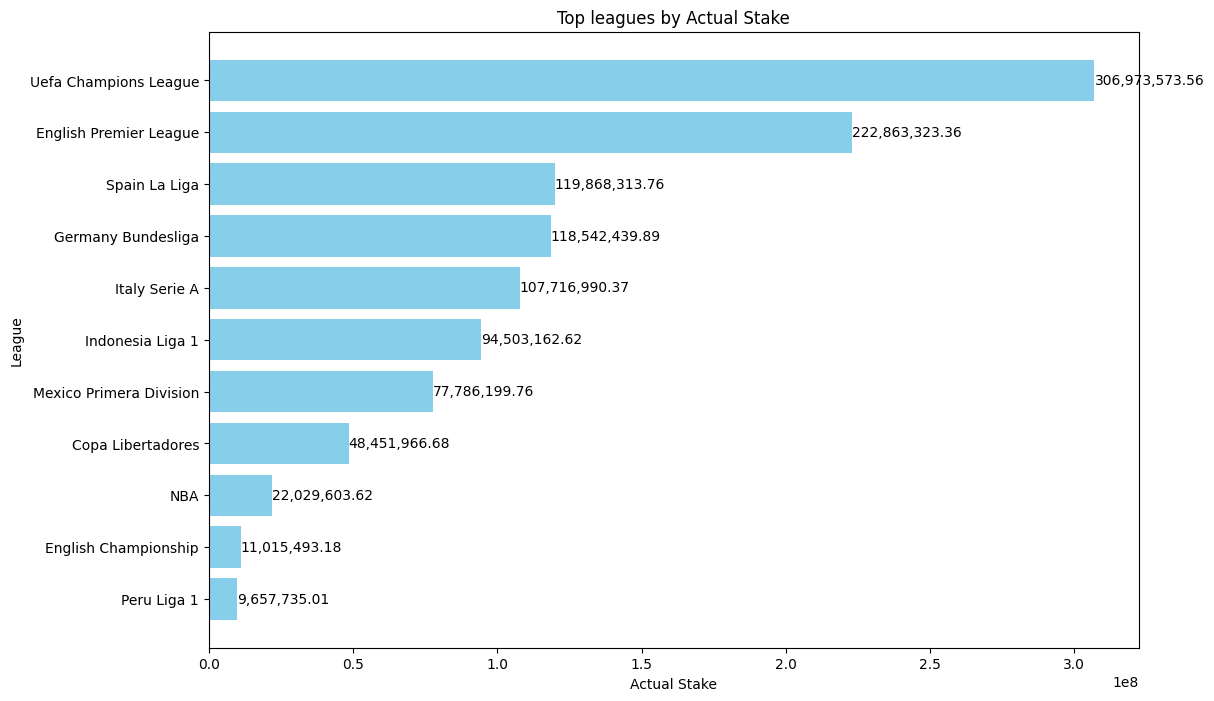

In [279]:
top_league_stake = data_cleaned_impute.groupby('LeagueName')['Actual_Stake'].sum().sort_values(ascending=False).head(11)

plt.figure(figsize=(12,8))

# Create a list of colors (Actual_Stake should generally be positive, so using a single color or a gradient)
bar_colors_stake = ['skyblue' for val in top_league_stake.values] # Using a consistent color as stake is usually positive

plt.barh(top_league_stake.index, top_league_stake.values, color=bar_colors_stake)
plt.xlabel("Actual Stake")
plt.ylabel("League")
plt.gca().invert_yaxis()
plt.title("Top leagues by Actual Stake")

# Add values on top of the bars
for index, value in enumerate(top_league_stake.values):
    plt.text(value, index, f'{value:,.2f}', va='center')

plt.show()

In [280]:
# Save the 'Top leagues by Actual Stake' plot as a high-resolution PNG
plt.figure(figsize=(12,6))
bar_colors_stake = ['skyblue' for val in top_league_stake.values]
plt.barh(top_league_stake.index, top_league_stake.values, color=bar_colors_stake)
plt.xlabel("Actual Stake")
plt.ylabel("League")
plt.gca().invert_yaxis()
plt.title("Top leagues by Actual Stake")
for index, value in enumerate(top_league_stake.values):
    plt.text(value, index, f'{value:,.2f}', va='center')
plt.savefig('top_leagues_actual_stake.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice



In [281]:
top_bet_type = data_cleaned_impute.groupby("BetType")["House_Profit_SGD"].sum().sort_values(ascending=False).head(10)
print(top_bet_type)

BetType
1    1.401464e+06
3    3.933834e+05
5    1.934668e+05
9    1.711770e+05
4    6.074830e+04
7    5.956778e+04
8    4.464057e+04
6    4.069349e+03
2    1.436556e+03
Name: House_Profit_SGD, dtype: float64


In [282]:
# Filter data for English Premier League
epl_data = data_cleaned_impute[data_cleaned_impute['LeagueName'] == 'English Premier League'].copy()

# Filter for March and April (months 3 and 4)
epl_march_april = epl_data[(epl_data['Month'] >= 3) & (epl_data['Month'] <= 4)].copy()

# Group by month and currency to see total stake
stake_by_month_currency = epl_march_april.groupby(['Month', 'CurrencyStr'])['Actual_Stake_SGD'].sum().unstack(fill_value=0)

print("Total Actual_Stake (SGD) for English Premier League by Month and Currency:")
display(stake_by_month_currency)

Total Actual_Stake (SGD) for English Premier League by Month and Currency:


CurrencyStr,AUD,BDT,BRL,CNY,COP,HKD,IDO,IDR,INR,LAK,MMK,MYR,NGN,THB,USD,VND,VNO
Month,,,,,,,,,,,,,,,,,
3,0.000000,0.000,4.84281,0.000000,0.00000,0.000000,0.000000,4.352754e+03,1.487808,0.000000,10.726000,0.00000,0.000,5.649908e+03,15.617988,47.95440,0.000000
4,94.202602,2.726,394.64279,9251.516157,290.21936,9840.847937,3235.052145,1.825987e+06,19.805000,4424.408171,7003.834228,8482.99501,0.811,1.824354e+06,42362.727213,173508.63786,1353.549444


In [283]:
bet_type_mapping = {


1: "Handicap",
2: "Odd/Even",
3: "Over/Under",
4: "Correct Score",
5: "1X2",
6: "total goal",
7: "First Half Handicap",
8: "First Half 1X2",
9: "First Half Over/Under"

}

data_cleaned_impute['BetTypeName'] = data_cleaned_impute['BetType'].map(bet_type_mapping)

# Display the top leagues again with their names
top_bet_type_names = data_cleaned_impute.groupby('BetTypeName')['House_Profit_SGD'].sum().sort_values(ascending=False).head(11)
print(top_bet_type_names)

BetTypeName
Handicap                 1.401464e+06
Over/Under               3.933834e+05
1X2                      1.934668e+05
First Half Over/Under    1.711770e+05
Correct Score            6.074830e+04
First Half Handicap      5.956778e+04
First Half 1X2           4.464057e+04
total goal               4.069349e+03
Odd/Even                 1.436556e+03
Name: House_Profit_SGD, dtype: float64


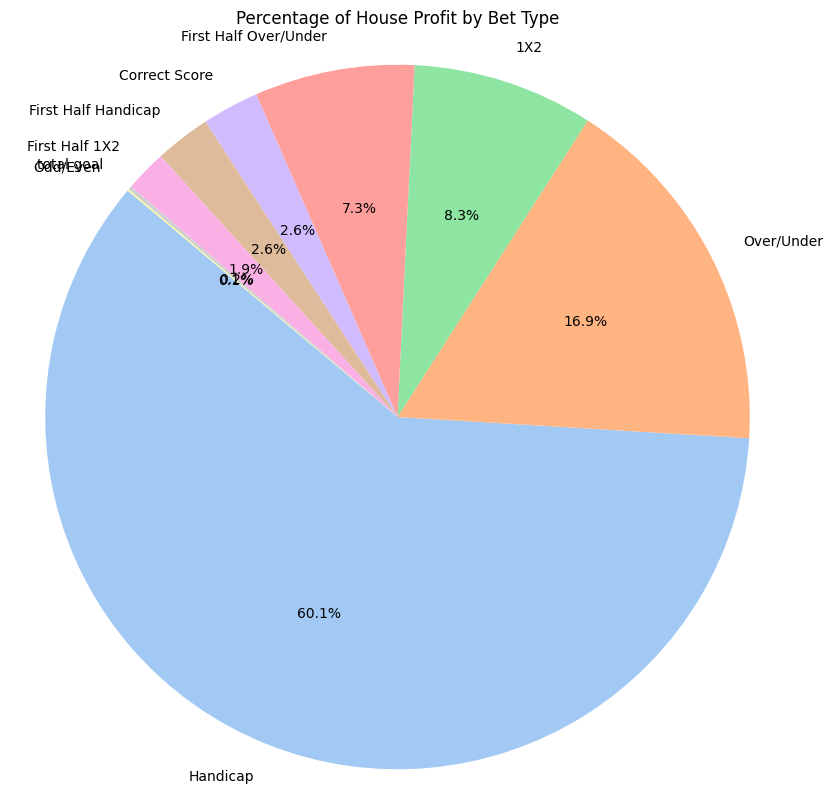

In [284]:
plt.figure(figsize=(10, 10))
plt.pie(top_bet_type_names, labels=top_bet_type_names.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage of House Profit by Bet Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [285]:
# Retrieve relevant metrics for 'Correct Score' bets
correct_score_profit_sgd = top_bet_type_names.get('Correct Score', 0)
correct_score_stake_sgd = data_cleaned_impute[data_cleaned_impute['BetTypeName'] == 'Correct Score']['Actual_Stake_SGD'].sum()

# Calculate profit margin for 'Correct Score'
correct_score_margin = (correct_score_profit_sgd / correct_score_stake_sgd) * 100 if correct_score_stake_sgd > 0 else 0

# Calculate volume percentage for 'Correct Score'
total_stake_sgd = data_cleaned_impute['Actual_Stake_SGD'].sum()
correct_score_volume_percentage = (correct_score_stake_sgd / total_stake_sgd) * 100 if total_stake_sgd > 0 else 0

# Overall margin (from previous analysis)
overall_margin = (total_net_profit / total_stake) * 100

print(f"Correct Score Profit (SGD): {correct_score_profit_sgd:,.2f}")
print(f"Correct Score Stake (SGD): {correct_score_stake_sgd:,.2f}")
print(f"Correct Score Profit Margin: {correct_score_margin:,.2f}%")
print(f"Correct Score Volume Percentage: {correct_score_volume_percentage:,.2f}%")
print(f"Overall Profit Margin: {overall_margin:,.2f}%")

Correct Score Profit (SGD): 60,748.30
Correct Score Stake (SGD): 133,407.67
Correct Score Profit Margin: 45.54%
Correct Score Volume Percentage: 0.62%
Overall Profit Margin: 10.85%


In [286]:
print("\n--- Analysis for All Bet Types ---\n")

for bet_type_name in data_cleaned_impute['BetTypeName'].dropna().unique():
    # Retrieve relevant metrics for the current bet type
    current_bet_type_profit_sgd = top_bet_type_names.get(bet_type_name, 0)
    current_bet_type_stake_sgd = data_cleaned_impute[data_cleaned_impute['BetTypeName'] == bet_type_name]['Actual_Stake_SGD'].sum()

    # Calculate profit margin for the current bet type
    current_bet_type_margin = (current_bet_type_profit_sgd / current_bet_type_stake_sgd) * 100 if current_bet_type_stake_sgd > 0 else 0

    # Calculate volume percentage for the current bet type
    current_bet_type_volume_percentage = (current_bet_type_stake_sgd / total_stake_sgd) * 100 if total_stake_sgd > 0 else 0

    print(f"Bet Type: {bet_type_name}")
    print(f"  Profit (SGD): {current_bet_type_profit_sgd:,.2f}")
    print(f"  Stake (SGD): {current_bet_type_stake_sgd:,.2f}")
    print(f"  Profit Margin: {current_bet_type_margin:,.2f}%")
    print(f"  Volume Percentage: {current_bet_type_volume_percentage:,.2f}%")
    print("--------------------------------------")



--- Analysis for All Bet Types ---

Bet Type: First Half Over/Under
  Profit (SGD): 171,177.01
  Stake (SGD): 2,257,339.93
  Profit Margin: 7.58%
  Volume Percentage: 10.51%
--------------------------------------
Bet Type: First Half Handicap
  Profit (SGD): 59,567.78
  Stake (SGD): 1,453,888.21
  Profit Margin: 4.10%
  Volume Percentage: 6.77%
--------------------------------------
Bet Type: Handicap
  Profit (SGD): 1,401,464.39
  Stake (SGD): 11,336,631.16
  Profit Margin: 12.36%
  Volume Percentage: 52.81%
--------------------------------------
Bet Type: Over/Under
  Profit (SGD): 393,383.45
  Stake (SGD): 5,520,219.77
  Profit Margin: 7.13%
  Volume Percentage: 25.71%
--------------------------------------
Bet Type: Odd/Even
  Profit (SGD): 1,436.56
  Stake (SGD): 20,847.12
  Profit Margin: 6.89%
  Volume Percentage: 0.10%
--------------------------------------
Bet Type: 1X2
  Profit (SGD): 193,466.76
  Stake (SGD): 565,507.73
  Profit Margin: 34.21%
  Volume Percentage: 2.63%
---

In [287]:
# Save the 'Percentage of House Profit by Bet Type' plot as a high-resolution PNG
plt.figure(figsize=(10, 10))
plt.pie(top_bet_type_names, labels=top_bet_type_names.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage of House Profit by Bet Type')
plt.axis('equal')
plt.savefig('house_profit_by_bet_type_pie_chart.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

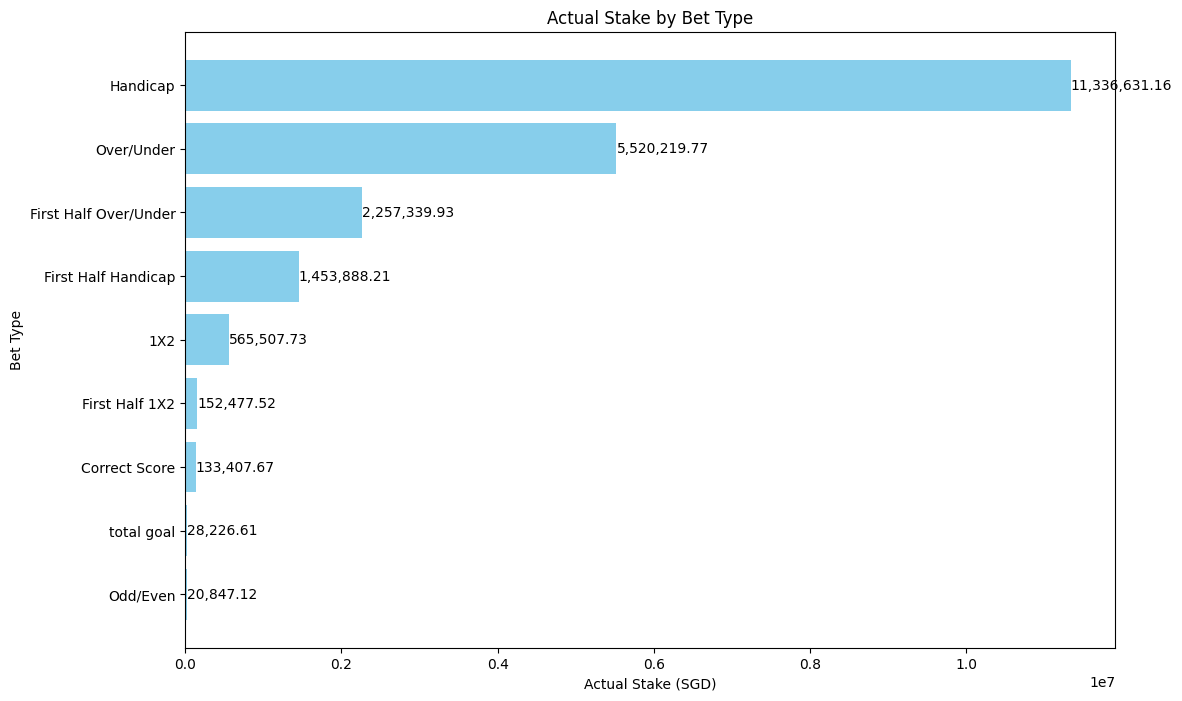

In [288]:
top_bet_type_stake = data_cleaned_impute.groupby('BetTypeName')['Actual_Stake_SGD'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,8))

# Actual_Stake is generally positive, so a consistent color or gradient is appropriate
bar_colors_bet_type_stake = ['skyblue' for val in top_bet_type_stake.values]

plt.barh(top_bet_type_stake.index, top_bet_type_stake.values, color=bar_colors_bet_type_stake)
plt.xlabel("Actual Stake (SGD)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("Actual Stake by Bet Type")

# Add values on top of the bars
for index, value in enumerate(top_bet_type_stake.values):
    plt.text(value, index, f'{value:,.2f}', va='center')

plt.show()

In [289]:
# Save the 'Actual Stake by Bet Type' plot as a high-resolution PNG
plt.figure(figsize=(12,8))
bar_colors_bet_type_stake = ['skyblue' for val in top_bet_type_stake.values]
plt.barh(top_bet_type_stake.index, top_bet_type_stake.values, color=bar_colors_bet_type_stake)
plt.xlabel("Actual Stake (SGD)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("Actual Stake by Bet Type")
for index, value in enumerate(top_bet_type_stake.values):
    plt.text(value, index, f'{value:,.2f}', va='center')
plt.savefig('actual_stake_by_bet_type.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

In [290]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

outliers_by_league = {}
for league in data_cleaned_impute['LeagueName'].dropna().unique():
    league_data = data_cleaned_impute[data_cleaned_impute['LeagueName'] == league]['House_Profit_SGD']
    outliers = detect_outliers_iqr(league_data)
    if not outliers.empty:
        outliers_by_league[league] = outliers

print("Valores atípicos detectados en los beneficios de la casa por liga:")
for league, outliers in outliers_by_league.items():
    print(f"\nLiga: {league}")
    display(outliers.describe())

Valores atípicos detectados en los beneficios de la casa por liga:

Liga: NBA


,House_Profit_SGD
count,3389.000000
mean,17.881062
std,301.189924
min,-2890.000000
25%,-84.016961
50%,42.500000
75%,98.878800
max,3473.370000



Liga: English Premier League


,House_Profit_SGD
count,27574.000000
mean,5.263430
std,222.631651
min,-5865.000000
25%,-34.680000
50%,19.296500
75%,38.593000
max,7718.600000



Liga: Copa Libertadores


...

,House_Profit_SGD
count,11647.000000
mean,1.464874
std,158.744576
min,-5788.950000
25%,-28.700346
50%,17.000000
75%,34.000000
max,4802.500000



Liga: Indonesia Liga 1


,House_Profit_SGD
count,20386.000000
mean,4.825773
std,133.285010
min,-2728.500000
25%,-24.650000
50%,15.790875
75%,27.746337
max,3859.300000



Liga: Uefa Champions League


,House_Profit_SGD
count,40067.000000
mean,25.514115
std,267.419526
min,-5287.000000
25%,-30.852157
50%,28.050000
75%,52.700000
max,8338.500000


In [291]:
handicap_profit_margin = (top_bet_type_names['Handicap'] / top_bet_type_stake['Handicap']) * 100
print(f"House Profit Margin for Handicap Bets: {handicap_profit_margin:.2f}%")

House Profit Margin for Handicap Bets: 12.36%


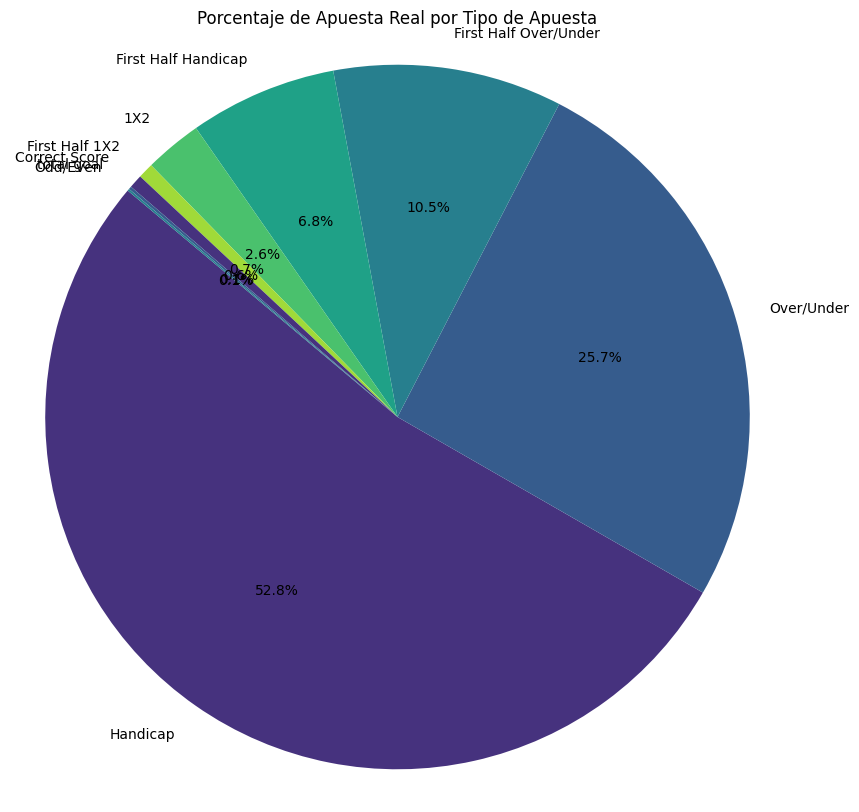

In [292]:
plt.figure(figsize=(10, 10))
plt.pie(top_bet_type_stake, labels=top_bet_type_stake.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Porcentaje de Apuesta Real por Tipo de Apuesta')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [293]:
# Guardar el gráfico de pastel 'Apuesta Real por Tipo de Apuesta' como PNG de alta resolución
plt.figure(figsize=(10, 10))
plt.pie(top_bet_type_stake, labels=top_bet_type_stake.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Porcentaje de Apuesta Real por Tipo de Apuesta')
plt.axis('equal')
plt.savefig('actual_stake_by_bet_type_pie_chart.png', dpi=300, bbox_inches='tight')
plt.close() # Cerrar el gráfico para evitar que se muestre dos veces

In [294]:
league_outcome_analysis = data_cleaned_impute.groupby(['LeagueName', 'LiveIndicator', 'Status']).size().unstack(fill_value=0)

# Calculate total bets for each League
league_outcome_analysis['Total'] = league_outcome_analysis.sum(axis=1)

# Calculate win/lose/draw probabilities
for status in ['WON', 'LOSE', 'DRAW']:
    if status in league_outcome_analysis.columns:
        league_outcome_analysis[f'{status}_Probability'] = (league_outcome_analysis[status] / league_outcome_analysis['Total']) * 100
    else:
        league_outcome_analysis[f'{status}_Probability'] = 0.0 # If a status is not present, its probability is 0

display(league_outcome_analysis.sort_values(by='Total', ascending=False).head(10))

Status                                 D.L.VOID   DRAW   LOSE  REFUND  VOID  \
LeagueName              LiveIndicator                                         
Uefa Champions League   False                 0   4535  78535       0    54   
                        True               1078   7116  53172       0   126   
English Premier League  True                  0   8421  48226       0     0   
Indonesia Liga 1        True                212  10563  45296       0    57   
Spain La Liga           True                166   6301  43417       0    10   
Germany Bundesliga      True                  0   5875  29153       0     0   
Italy Serie A           True                  0   4984  28333       0     0   
Mexico Primera Division True                  0   5670  25005       0     0   
English Premier League  False                 0   5821  23622       0     0   
Indonesia Liga 1        False                 0   3033  17775       0    20   

Status                                   WON   Total  WON_Probability  \
LeagueName              LiveIndicator                                   
Uefa Champions League   False          25839  108963        23.713554   
                        True           28968   90460        32.022994   
English Premier League  True           32785   89432        36.659138   
Indonesia Liga 1        True           32602   88730        36.742928   
Spain La Liga           True           29965   79859        37.522383   
Germany Bundesliga      True           26502   61530        43.071672   
Italy Serie A           True           19632   52949        37.077187   
Mexico Primera Division True           21341   52016        41.027761   
English Premier League  False          16872   46315        36.428803   
Indonesia Liga 1        False          11852   32680        36.266830   

Status                                 LOSE_Probability  DRAW_Probability  
LeagueName              LiveIndicator                                      
Uefa Champions League   False                 72.074925          4.161963  
                        True                  58.779571          7.866460  
English Premier League  True                  53.924770          9.416093  
Indonesia Liga 1        True                  51.049251         11.904655  
Spain La Liga           True                  54.367072          7.890156  
Germany Bundesliga      True                  47.380140          9.548188  
Italy Serie A           True                  53.509981          9.412831  
Mexico Primera Division True                  48.071747         10.900492  
English Premier League  False                 51.002915         12.568282  
Indonesia Liga 1        False                 54.391065          9.280906

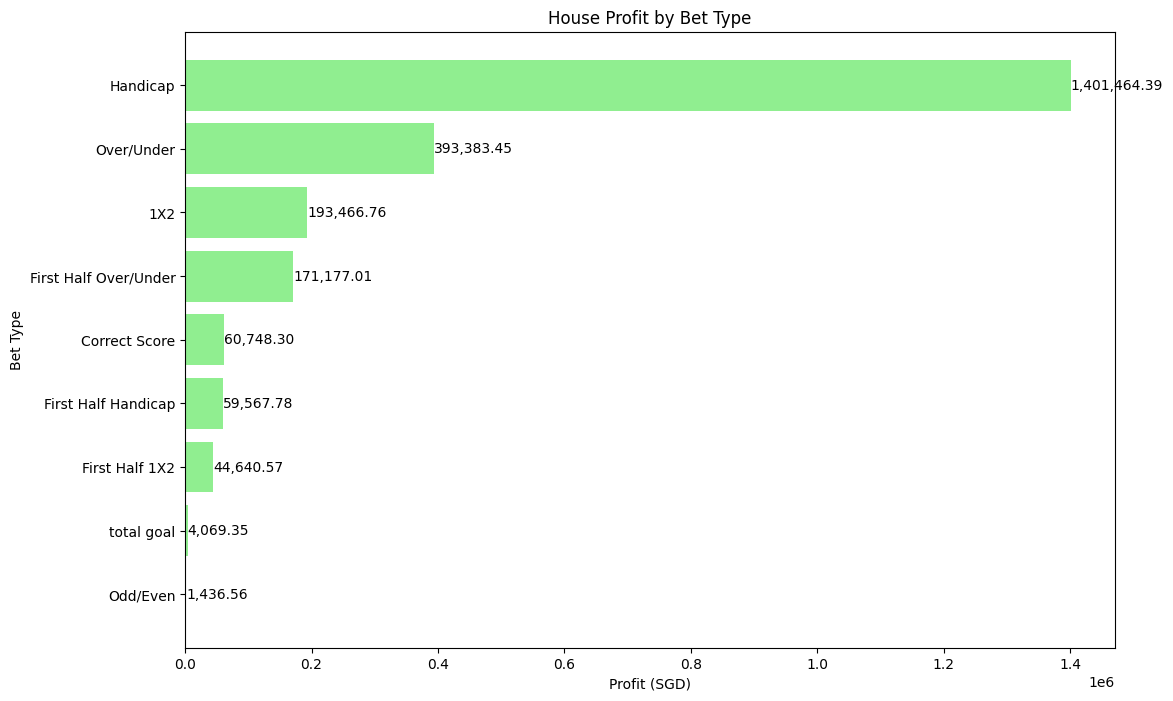

In [295]:
plt.figure(figsize=(12,8))

# Create a list of colors based on profit values (all are positive here)
bar_colors_bet_type = ['lightgreen' if val > 0 else 'lightcoral' for val in top_bet_type_names.values]

plt.barh(top_bet_type_names.index, top_bet_type_names.values, color=bar_colors_bet_type)
plt.xlabel("Profit (SGD)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("House Profit by Bet Type")

# Add values on top of the bars
for index, value in enumerate(top_bet_type_names.values):
    plt.text(value, index, f'{value:,.2f}', va='center')

plt.show()

To insert this chart into PowerPoint, you can save it as a high-resolution image file. I will generate the code to save it as a PNG.

### Probability of Win/Lose/Draw based on League

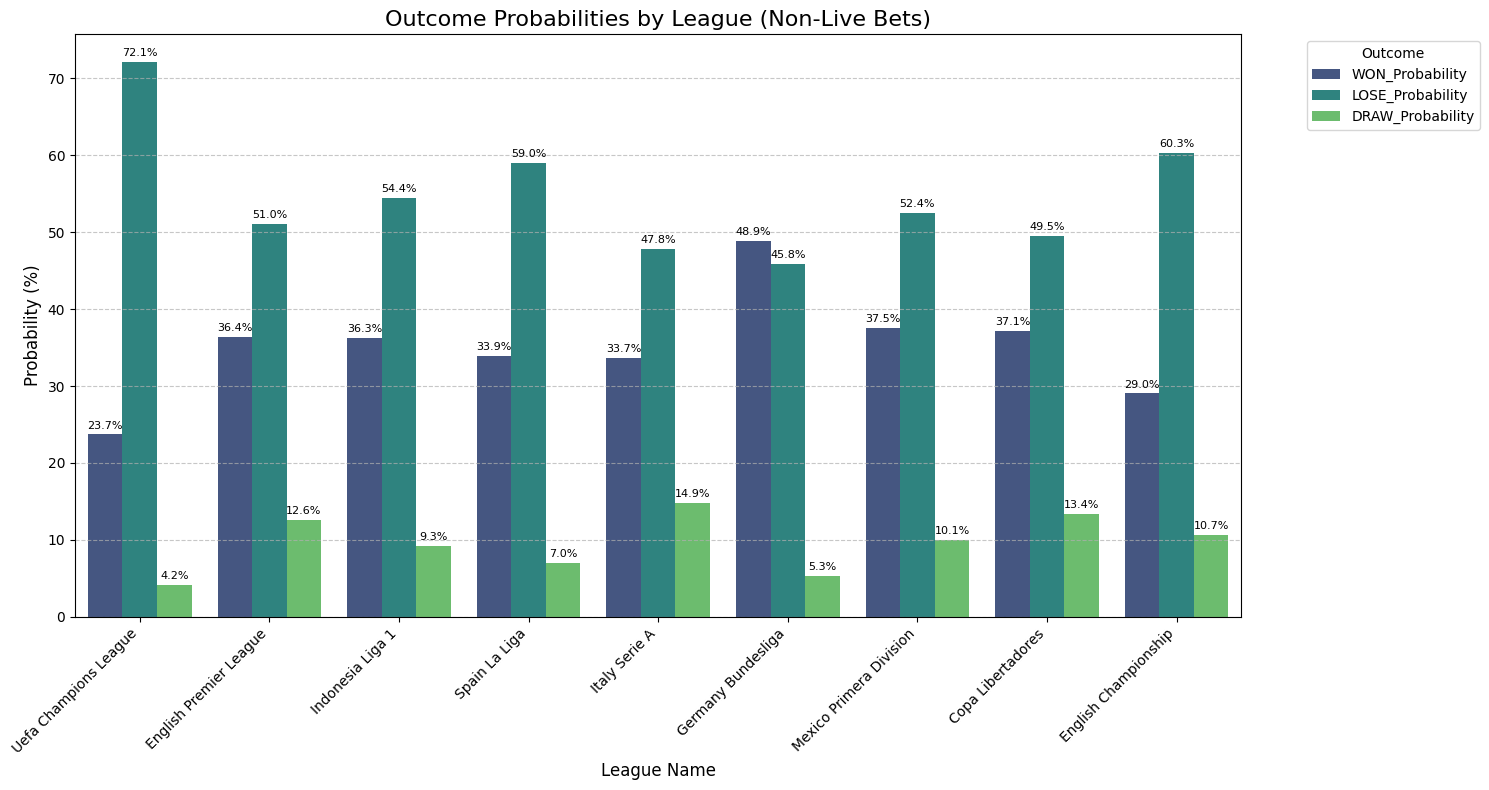

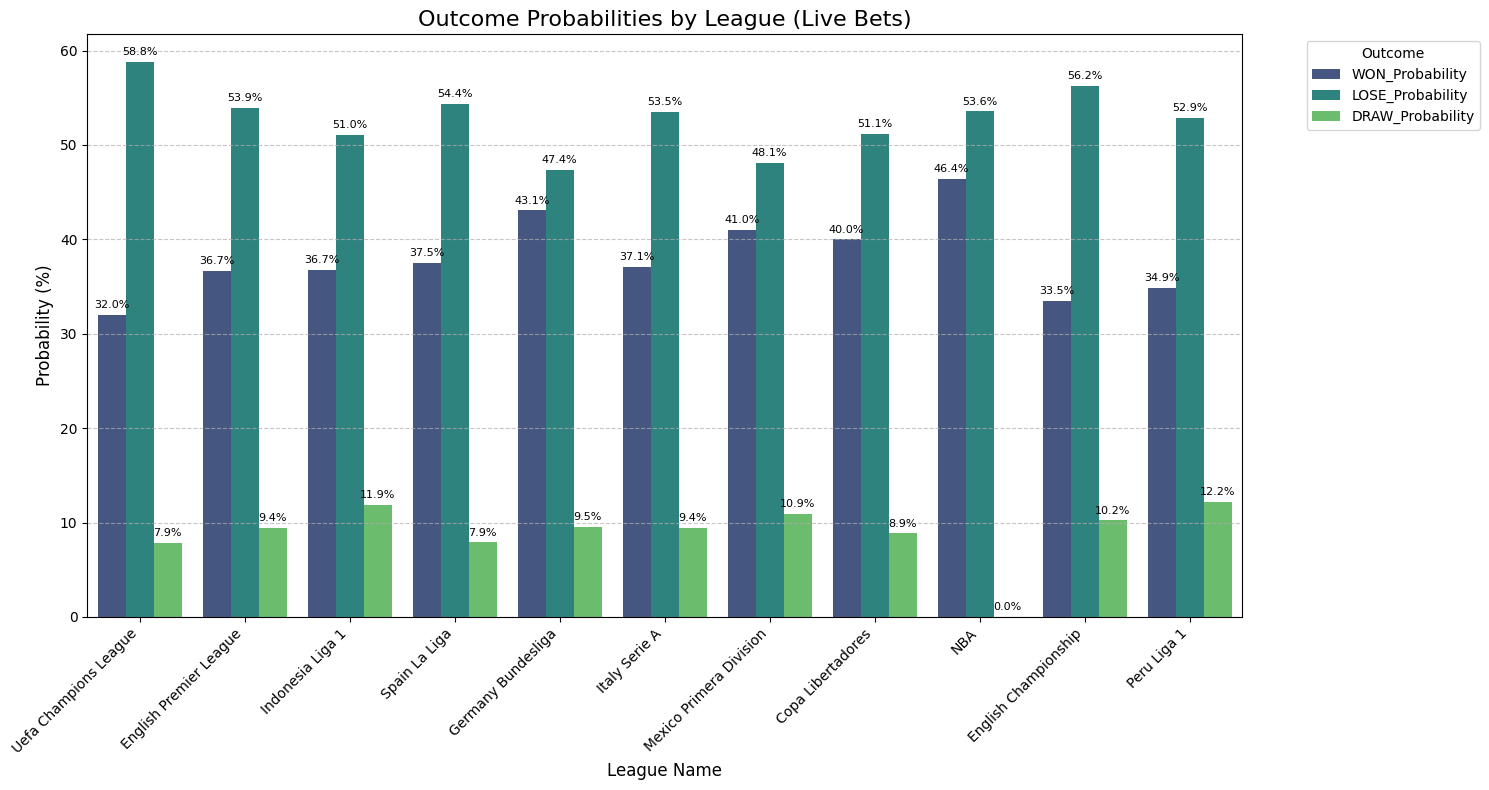

In [296]:

# Select the top 10 leagues by total bets for visualization
top_leagues_by_bets = league_outcome_analysis.sort_values(by='Total', ascending=False).head(20).index
plot_data_league = league_outcome_analysis.loc[top_leagues_by_bets, ['WON_Probability', 'LOSE_Probability', 'DRAW_Probability']].reset_index()
plot_data_league_melted = plot_data_league.melt(id_vars=['LeagueName', 'LiveIndicator'], var_name='Outcome', value_name='Probability')

# Create a plot for Non-Live bets
plt.figure(figsize=(15, 8))
data_non_live = plot_data_league_melted[plot_data_league_melted['LiveIndicator'] == False]
sns.barplot(x='LeagueName', y='Probability', hue='Outcome', data=data_non_live, palette='viridis')
plt.title('Outcome Probabilities by League (Non-Live Bets)', fontsize=16)
plt.xlabel('League Name', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in plt.gca().containers:
    for bar in container:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Create a plot for Live bets
plt.figure(figsize=(15, 8))
data_live = plot_data_league_melted[plot_data_league_melted['LiveIndicator'] == True]
sns.barplot(x='LeagueName', y='Probability', hue='Outcome', data=data_live, palette='viridis')
plt.title('Outcome Probabilities by League (Live Bets)', fontsize=16)
plt.xlabel('League Name', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in plt.gca().containers:
    for bar in container:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [297]:
# Save the 'Outcome Probabilities by League' plots as high-resolution PNGs

# Prepare data for plotting win, lose, and draw probabilities for the top leagues
top_leagues_by_bets = league_outcome_analysis.sort_values(by='Total', ascending=False).head(20).index
plot_data_league = league_outcome_analysis.loc[top_leagues_by_bets, ['WON_Probability', 'LOSE_Probability', 'DRAW_Probability']].reset_index()
plot_data_league_melted = plot_data_league.melt(id_vars=['LeagueName', 'LiveIndicator'], var_name='Outcome', value_name='Probability')

# Save plot for Non-Live bets
plt.figure(figsize=(15, 8))
data_non_live = plot_data_league_melted[plot_data_league_melted['LiveIndicator'] == False]
sns.barplot(x='LeagueName', y='Probability', hue='Outcome', data=data_non_live, palette='viridis')
plt.title('Outcome Probabilities by League (Non-Live Bets)', fontsize=16)
plt.xlabel('League Name', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in plt.gca().containers:
    for bar in container:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('outcome_probabilities_by_league_non_live.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot

# Save plot for Live bets
plt.figure(figsize=(15, 8))
data_live = plot_data_league_melted[plot_data_league_melted['LiveIndicator'] == True]
sns.barplot(x='LeagueName', y='Probability', hue='Outcome', data=data_live, palette='viridis')
plt.title('Outcome Probabilities by League (Live Bets)', fontsize=16)
plt.xlabel('League Name', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in plt.gca().containers:
    for bar in container:
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('outcome_probabilities_by_league_live.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot

In [298]:
bet_type_profit_margin = (top_bet_type_names / top_bet_type_stake) * 100
bet_type_profit_margin = bet_type_profit_margin.sort_values(ascending=False)
print("Profit Margin by Bet Type (%):\n")
print(bet_type_profit_margin)

Profit Margin by Bet Type (%):

BetTypeName
Correct Score            45.535838
1X2                      34.211160
First Half 1X2           29.276823
total goal               14.416714
Handicap                 12.362265
First Half Over/Under     7.583130
Over/Under                7.126228
Odd/Even                  6.890909
First Half Handicap       4.097136
dtype: float64


In [299]:
# Save the 'House Profit by Bet Type' plot as a high-resolution PNG
plt.figure(figsize=(12,8))
bar_colors_bet_type = ['lightgreen' if val > 0 else 'lightcoral' for val in top_bet_type_names.values]
plt.barh(top_bet_type_names.index, top_bet_type_names.values, color=bar_colors_bet_type)
plt.xlabel("Profit (SGD)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("House Profit by Bet Type")
for index, value in enumerate(top_bet_type_names.values):
    plt.text(value, index, f'{value:,.2f}', va='center')
plt.savefig('house_profit_by_bet_type.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

In [300]:
# Save the 'Volumen de Apuestas vs. Margen de Utilidad por Tipo de Apuesta' plot as a high-resolution PNG

# Ensure both Series are aligned by index (BetTypeName)
combined_df_save = pd.DataFrame({
    'Actual_Stake': top_bet_type_stake,
    'Profit_Margin': bet_type_profit_margin
}).reset_index()
combined_df_save.rename(columns={'index': 'BetTypeName'}, inplace=True)

# Sort by profit margin for better visualization
combined_df_save = combined_df_save.sort_values(by='Profit_Margin', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot Actual Stake on the primary Y-axis
sns.barplot(x='BetTypeName', y='Actual_Stake', data=combined_df_save, ax=ax1, hue='BetTypeName', palette='viridis', legend=False)
ax1.set_xlabel('Tipo de Apuesta')
ax1.set_ylabel('Volumen de Apuestas (Actual Stake)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_title('Volumen de Apuestas vs. Margen de Utilidad por Tipo de Apuesta')
ax1.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.xticks(rotation=45, ha='right')

# Create a secondary Y-axis for Profit Margin
ax2 = ax1.twinx()
sns.lineplot(x='BetTypeName', y='Profit_Margin', data=combined_df_save, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Margen de Utilidad (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, combined_df_save['Profit_Margin'].max() * 1.1) # Set y-axis limit slightly above max margin

# Add profit margin values on the line plot
for x, y in zip(combined_df_save['BetTypeName'], combined_df_save['Profit_Margin']):
    ax2.text(x, y + 0.05, f'{y:.2f}%', color='red', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bet_volume_vs_profit_margin_by_bet_type.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

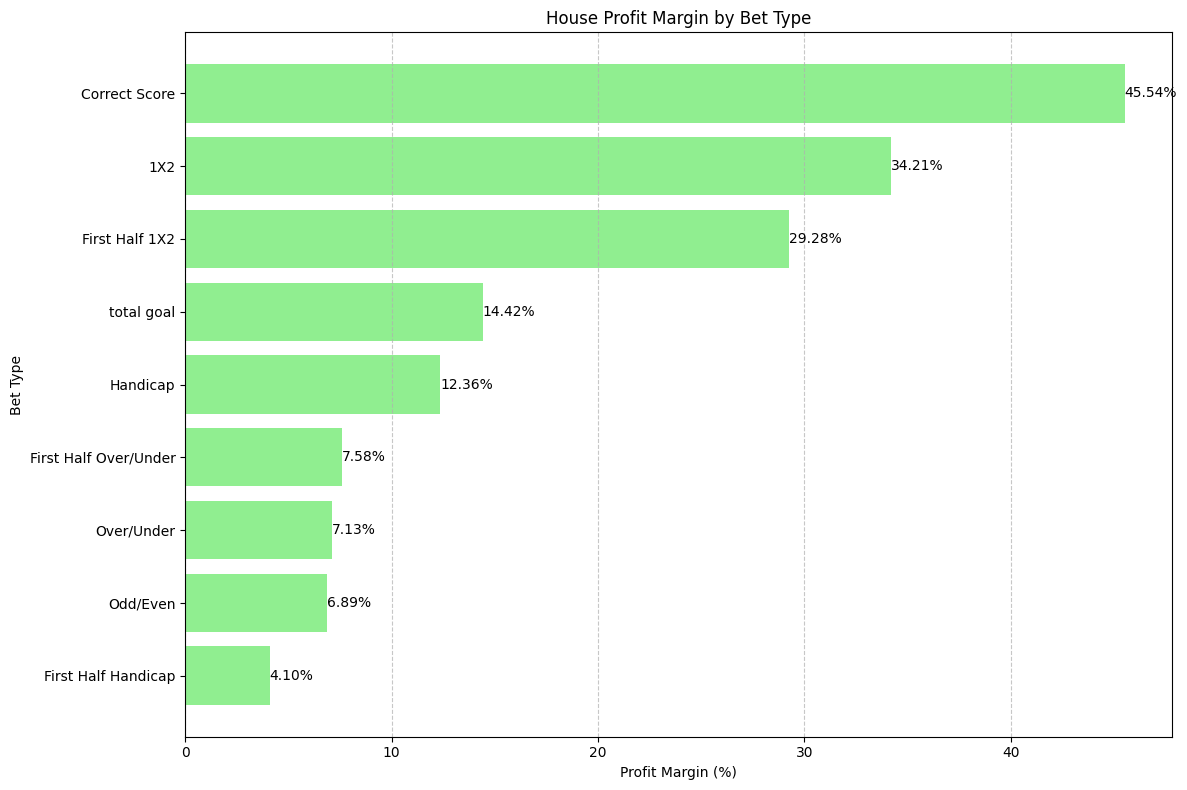

In [301]:
plt.figure(figsize=(12, 8))

# Create a list of colors based on profit margin values
bar_colors_profit_margin = ['lightgreen' if val > 0 else 'lightcoral' for val in bet_type_profit_margin.values]

plt.barh(bet_type_profit_margin.index, bet_type_profit_margin.values, color=bar_colors_profit_margin)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("House Profit Margin by Bet Type")

# Add values on top of the bars
for index, value in enumerate(bet_type_profit_margin.values):
    plt.text(value, index, f'{value:,.2f}%', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

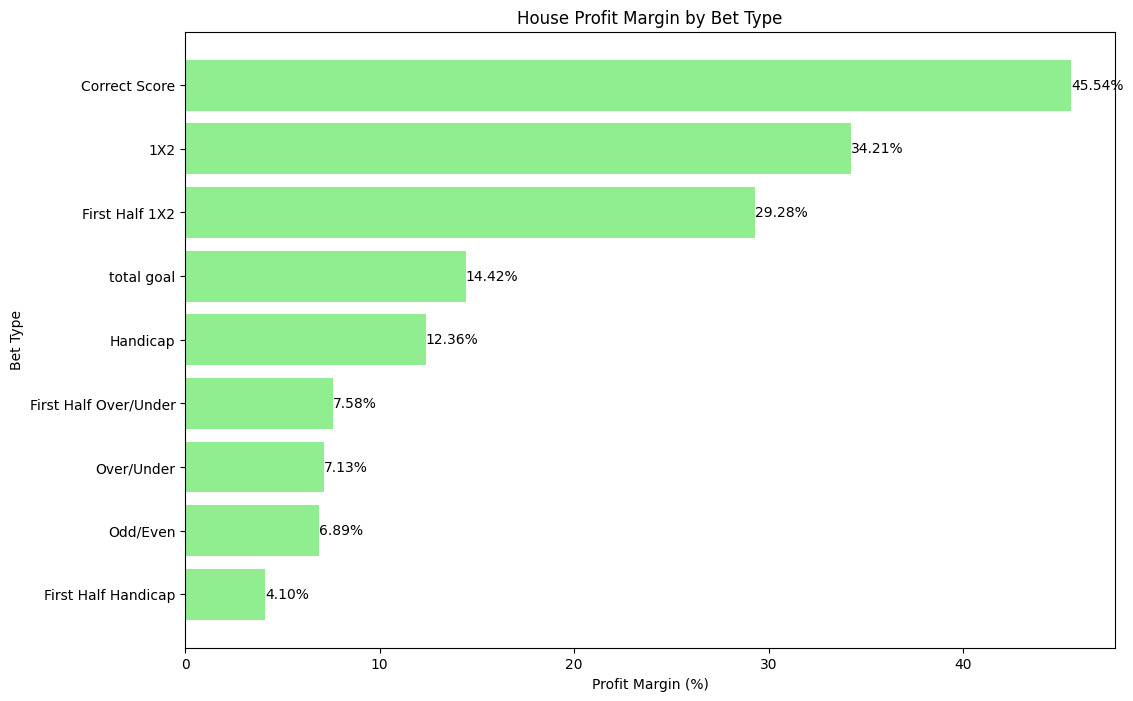

In [302]:
plt.figure(figsize=(12, 8))

# Create a list of colors based on profit margin values
bar_colors_profit_margin = ['lightgreen' if val > 0 else 'lightcoral' for val in bet_type_profit_margin.values]

plt.barh(bet_type_profit_margin.index, bet_type_profit_margin.values, color=bar_colors_profit_margin)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("House Profit Margin by Bet Type")

# Add values on top of the bars
for index, value in enumerate(bet_type_profit_margin.values):
    plt.text(value, index, f'{value:,.2f}%', va='center')

plt.show()

In [303]:
# Save the 'House Profit Margin by Bet Type' plot as a high-resolution PNG
plt.figure(figsize=(12, 8))
bar_colors_profit_margin = ['lightgreen' if val > 0 else 'lightcoral' for val in bet_type_profit_margin.values]
plt.barh(bet_type_profit_margin.index, bet_type_profit_margin.values, color=bar_colors_profit_margin)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Bet Type")
plt.gca().invert_yaxis()
plt.title("House Profit Margin by Bet Type")
for index, value in enumerate(bet_type_profit_margin.values):
    plt.text(value, index, f'{value:,.2f}%', va='center')
plt.savefig('house_profit_margin_by_bet_type.png', dpi=300, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying twice

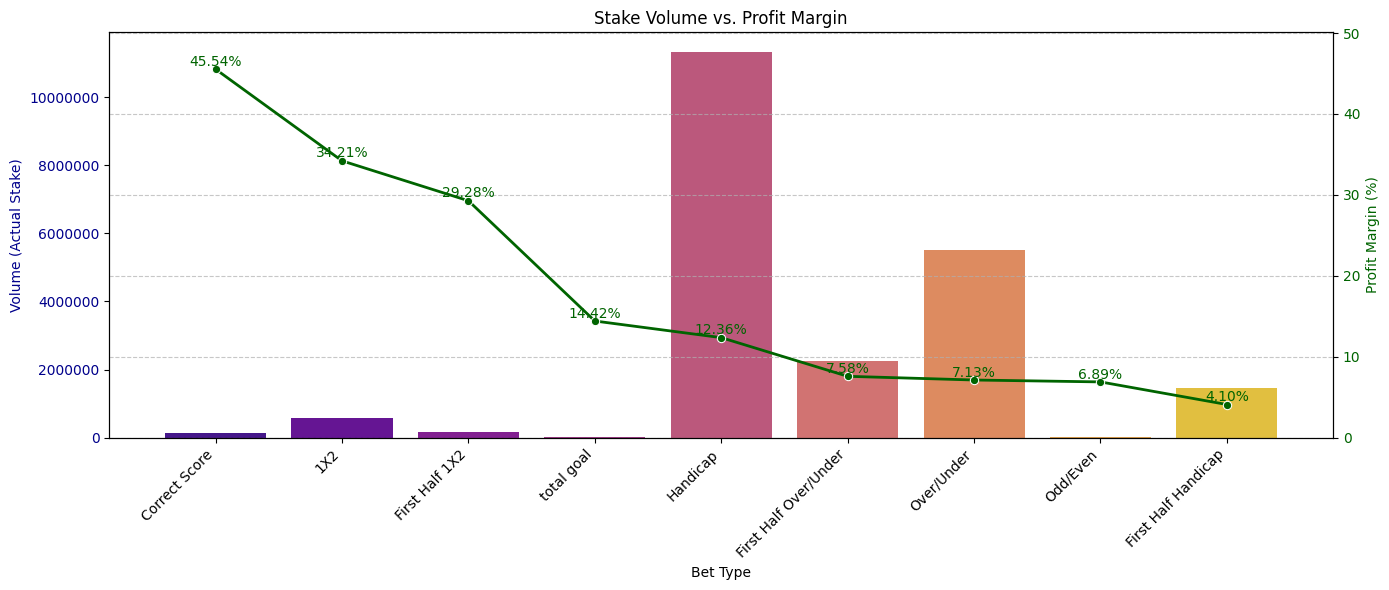

In [304]:

# Ensure both Series are aligned by index (BetTypeName)
combined_df = pd.DataFrame({
    'Actual_Stake': top_bet_type_stake,
    'Profit_Margin': bet_type_profit_margin
}).reset_index()
combined_df.rename(columns={'index': 'BetTypeName'}, inplace=True)

# Sort by profit margin for better visualization
combined_df = combined_df.sort_values(by='Profit_Margin', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Actual Stake on the primary Y-axis
sns.barplot(x='BetTypeName', y='Actual_Stake', data=combined_df, ax=ax1, hue='BetTypeName', palette='plasma', legend=False)
ax1.set_xlabel('Bet Type')
ax1.set_ylabel('Volume (Actual Stake)', color='darkblue') # Changed color to 'darkblue'
ax1.tick_params(axis='y', labelcolor='darkblue') # Changed tick label color to 'darkblue'
ax1.set_title('Stake Volume vs. Profit Margin')
ax1.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.xticks(rotation=45, ha='right')

# Create a secondary Y-axis for Profit Margin
ax2 = ax1.twinx()
sns.lineplot(x='BetTypeName', y='Profit_Margin', data=combined_df, ax=ax2, color='darkgreen', marker='o', linewidth=2)
ax2.set_ylabel('Profit Margin (%)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_ylim(0, combined_df['Profit_Margin'].max() * 1.1) # Set y-axis limit slightly above max margin

# Add profit margin values on the line plot
for x, y in zip(combined_df['BetTypeName'], combined_df['Profit_Margin']):
    ax2.text(x, y + 0.05, f'{y:.2f}%', color='darkgreen', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### House Profit by Live Indicator

In [305]:
profit_by_live_indicator = data_cleaned_impute.groupby('LiveIndicator')['House_Profit_SGD'].sum().reset_index()
display(profit_by_live_indicator)

,LiveIndicator,House_Profit_SGD
0,False,1.163288e+06
1,True,1.166666e+06
